# Hyperparameter Tuning - Heart Disease Dataset

Techniques: Grid Search, Cross-Validation, Seed Experiments, Optuna

Models: Logistic Regression, XGBoost

Dataset: Cleveland Heart Disease (303 samples, 13 features)

Experiment tracking with MLflow

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All imports successful')

All imports successful


## 1. Load and Preprocess Data

In [3]:
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
    'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
]

df = pd.read_csv('data/raw/processed.cleveland.data', header=None, names=column_names)

print(f'Dataset shape: {df.shape}')
print('\nFirst few rows:')
print(df.head())
print('\nColumn info:')
print(df.dtypes)
print("\nMissing values (as '?'):")
print((df == '?').sum())

Dataset shape: (303, 14)

First few rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  num  
0    3.0  0.0  6.0    0  
1    2.0  3.0  3.0    2  
2    2.0  2.0  7.0    1  
3    3.0  0.0  3.0    0  
4    1.0  0.0  3.0    0  

Column info:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
num           int64
dtype: object

Missing values (as '?'):
age  

In [4]:
df = df.replace('?', np.nan)
print(f'Rows with NaN before dropping: {len(df)}')
df = df.dropna()
print(f'Rows after dropping NaN: {len(df)}')

df['ca'] = df['ca'].astype(float)
df['thal'] = df['thal'].astype(float)

y = (df['num'] > 0).astype(int)
X = df.drop('num', axis=1)

print('\nTarget distribution (binary):')
print(y.value_counts())
print(f"\nNo disease (0): {(y==0).sum()} ({(y==0).mean()*100:.1f}%")
print(f"Heart disease (1): {(y==1).sum()} ({(y==1).mean()*100:.1f}%")

Rows with NaN before dropping: 303
Rows after dropping NaN: 297

Target distribution (binary):
num
0    160
1    137
Name: count, dtype: int64

No disease (0): 160 (53.9%
Heart disease (1): 137 (46.1%


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'X_train shape: {X_train.shape}, X_test shape: {X_test.shape}')
print(f'Train target distribution: {y_train.value_counts().to_dict()}')
print(f'Test target distribution: {y_test.value_counts().to_dict()}')

X_train shape: (237, 13), X_test shape: (60, 13)
Train target distribution: {0: 128, 1: 109}
Test target distribution: {0: 32, 1: 28}


## 2. Baseline Models (MLflow Tracked)

In [6]:
mlflow.set_experiment('heart_disease_hyperparameter_tuning')

baseline_results = {}

with mlflow.start_run(run_name='baseline_logistic'):
    log_model = LogisticRegression(max_iter=1000, random_state=42)
    log_model.fit(X_train_scaled, y_train)
    y_pred = log_model.predict(X_test_scaled)
    y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    mlflow.log_param('model', 'LogisticRegression')
    mlflow.log_param('random_state', 42)
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('precision', prec)
    mlflow.log_metric('recall', rec)
    mlflow.log_metric('f1', f1)
    mlflow.log_metric('roc_auc', roc_auc)
    
    baseline_results['Logistic'] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc_auc}
    print(f'Logistic Regression - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}')

with mlflow.start_run(run_name='baseline_xgboost'):
    xgb_model = XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0)
    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    mlflow.log_param('model', 'XGBClassifier')
    mlflow.log_param('random_state', 42)
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('precision', prec)
    mlflow.log_metric('recall', rec)
    mlflow.log_metric('f1', f1)
    mlflow.log_metric('roc_auc', roc_auc)
    
    baseline_results['XGBoost'] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc_auc}
    print(f'XGBoost - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}')

Logistic Regression - Accuracy: 0.8333, Precision: 0.8462, Recall: 0.7857, F1: 0.8148, ROC-AUC: 0.9498
XGBoost - Accuracy: 0.8667, Precision: 0.8846, Recall: 0.8214, F1: 0.8519, ROC-AUC: 0.8917


## 3. Cross-Validation Analysis

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

with mlflow.start_run(run_name='cv_logistic'):
    log_model = LogisticRegression(max_iter=1000, random_state=42)
    scores = cross_val_score(log_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_results['Logistic'] = scores
    
    mlflow.log_param('model', 'LogisticRegression')
    mlflow.log_param('cv', 5)
    mlflow.log_metric('cv_mean', scores.mean())
    mlflow.log_metric('cv_std', scores.std())
    
    print(f'Logistic Regression CV - Mean: {scores.mean():.4f}, Std: {scores.std():.4f}')
    print(f'  Scores: {[format(s, ".4f") for s in scores]}')

with mlflow.start_run(run_name='cv_xgboost'):
    xgb_model = XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0)
    scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_results['XGBoost'] = scores
    
    mlflow.log_param('model', 'XGBClassifier')
    mlflow.log_param('cv', 5)
    mlflow.log_metric('cv_mean', scores.mean())
    mlflow.log_metric('cv_std', scores.std())
    
    print(f'XGBoost CV - Mean: {scores.mean():.4f}, Std: {scores.std():.4f}')
    print(f'  Scores: {[format(s, ".4f") for s in scores]}')

Logistic Regression CV - Mean: 0.8269, Std: 0.0592
  Scores: ['0.8958', '0.7917', '0.7447', '0.8936', '0.8085']
XGBoost CV - Mean: 0.7677, Std: 0.0608
  Scores: ['0.8125', '0.7708', '0.6809', '0.8511', '0.7234']


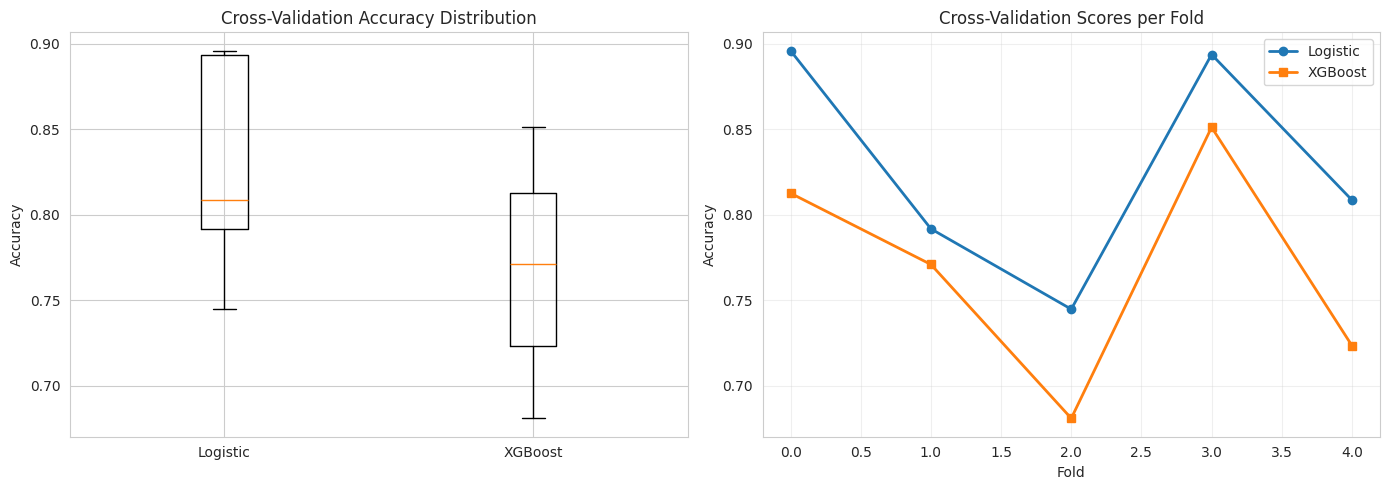

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].boxplot([cv_results['Logistic'], cv_results['XGBoost']], labels=['Logistic', 'XGBoost'])
ax[0].set_title('Cross-Validation Accuracy Distribution')
ax[0].set_ylabel('Accuracy')

x = np.arange(len(cv_results['Logistic']))
ax[1].plot(x, cv_results['Logistic'], marker='o', label='Logistic', linewidth=2)
ax[1].plot(x, cv_results['XGBoost'], marker='s', label='XGBoost', linewidth=2)
ax[1].set_title('Cross-Validation Scores per Fold')
ax[1].set_xlabel('Fold')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Grid Search Hyperparameter Tuning

In [9]:
log_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000, 2000]
}

with mlflow.start_run(run_name='gridsearch_logistic'):
    log_grid = GridSearchCV(
        LogisticRegression(random_state=42),
        log_param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    log_grid.fit(X_train_scaled, y_train)
    
    mlflow.log_params(log_grid.best_params_)
    mlflow.log_metric('best_cv_score', log_grid.best_score_)
    
    y_pred = log_grid.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    mlflow.log_metric('test_accuracy', test_acc)
    
    print(f'Best Logistic Params: {log_grid.best_params_}')
    print(f'Best CV Score: {log_grid.best_score_:.4f}')
    print(f'Test Accuracy: {test_acc:.4f}')
    
    log_best = log_grid.best_estimator_

log_grid_results = pd.DataFrame(log_grid.cv_results_)
print('\nTop 5 Logistic configurations:')
print(log_grid_results[['params', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False).head())

Best Logistic Params: {'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}
Best CV Score: 0.8305
Test Accuracy: 0.8667

Top 5 Logistic configurations:
                                               params  mean_test_score  \
1    {'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}         0.830496   
3    {'C': 0.01, 'max_iter': 2000, 'solver': 'lbfgs'}         0.830496   
6   {'C': 0.1, 'max_iter': 2000, 'solver': 'liblin...         0.830496   
4   {'C': 0.1, 'max_iter': 1000, 'solver': 'liblin...         0.830496   
10  {'C': 1, 'max_iter': 2000, 'solver': 'liblinear'}         0.822074   

    std_test_score  
1         0.082410  
3         0.082410  
6         0.079187  
4         0.079187  
10        0.076411  


In [10]:
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

with mlflow.start_run(run_name='gridsearch_xgboost'):
    xgb_grid = GridSearchCV(
        XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
        xgb_param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    xgb_grid.fit(X_train, y_train)
    
    mlflow.log_params(xgb_grid.best_params_)
    mlflow.log_metric('best_cv_score', xgb_grid.best_score_)
    
    y_pred = xgb_grid.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    mlflow.log_metric('test_accuracy', test_acc)
    
    print(f'Best XGBoost Params: {xgb_grid.best_params_}')
    print(f'Best CV Score: {xgb_grid.best_score_:.4f}')
    print(f'Test Accuracy: {test_acc:.4f}')
    
    xgb_best = xgb_grid.best_estimator_

xgb_grid_results = pd.DataFrame(xgb_grid.cv_results_)
print('\nTop 5 XGBoost configurations:')
print(xgb_grid_results[['params', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False).head())

Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best CV Score: 0.8305
Test Accuracy: 0.8667

Top 5 XGBoost configurations:
                                               params  mean_test_score  \
24  {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...         0.830496   
12  {'learning_rate': 0.01, 'max_depth': 7, 'n_est...         0.817908   
18  {'learning_rate': 0.01, 'max_depth': 9, 'n_est...         0.817908   
6   {'learning_rate': 0.01, 'max_depth': 5, 'n_est...         0.813652   
20  {'learning_rate': 0.01, 'max_depth': 9, 'n_est...         0.813652   

    std_test_score  
24        0.080183  
12        0.066355  
18        0.066355  
6         0.068822  
20        0.071404  


## 5. Seed Experiments (Random State Sensitivity)

In [11]:
seeds = [0, 1, 42, 100, 999, 1234, 2024, 777, 314, 123]
seed_results = {'Logistic': [], 'XGBoost': []}

for seed in seeds:
    with mlflow.start_run(run_name=f'seed_logistic_{seed}'):
        log_model = LogisticRegression(max_iter=1000, random_state=seed)
        log_model.fit(X_train_scaled, y_train)
        y_pred = log_model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        seed_results['Logistic'].append(acc)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('accuracy', acc)
    
    with mlflow.start_run(run_name=f'seed_xgboost_{seed}'):
        xgb_model = XGBClassifier(eval_metric='logloss', random_state=seed, verbosity=0)
        xgb_model.fit(X_train, y_train)
        y_pred = xgb_model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        seed_results['XGBoost'].append(acc)
        mlflow.log_param('random_state', seed)
        mlflow.log_metric('accuracy', acc)

seed_df = pd.DataFrame({'Seed': seeds, 'Logistic': seed_results['Logistic'], 'XGBoost': seed_results['XGBoost']})
print('Results per seed:')
print(seed_df.to_string(index=False))
print(f"\nLogistic - Mean: {np.mean(seed_results['Logistic']):.4f}, Std: {np.std(seed_results['Logistic']):.4f}")
print(f"XGBoost   - Mean: {np.mean(seed_results['XGBoost']):.4f}, Std: {np.std(seed_results['XGBoost']):.4f}")

Results per seed:
 Seed  Logistic  XGBoost
    0  0.833333 0.866667
    1  0.833333 0.866667
   42  0.833333 0.866667
  100  0.833333 0.866667
  999  0.833333 0.866667
 1234  0.833333 0.866667
 2024  0.833333 0.866667
  777  0.833333 0.866667
  314  0.833333 0.866667
  123  0.833333 0.866667

Logistic - Mean: 0.8333, Std: 0.0000
XGBoost   - Mean: 0.8667, Std: 0.0000


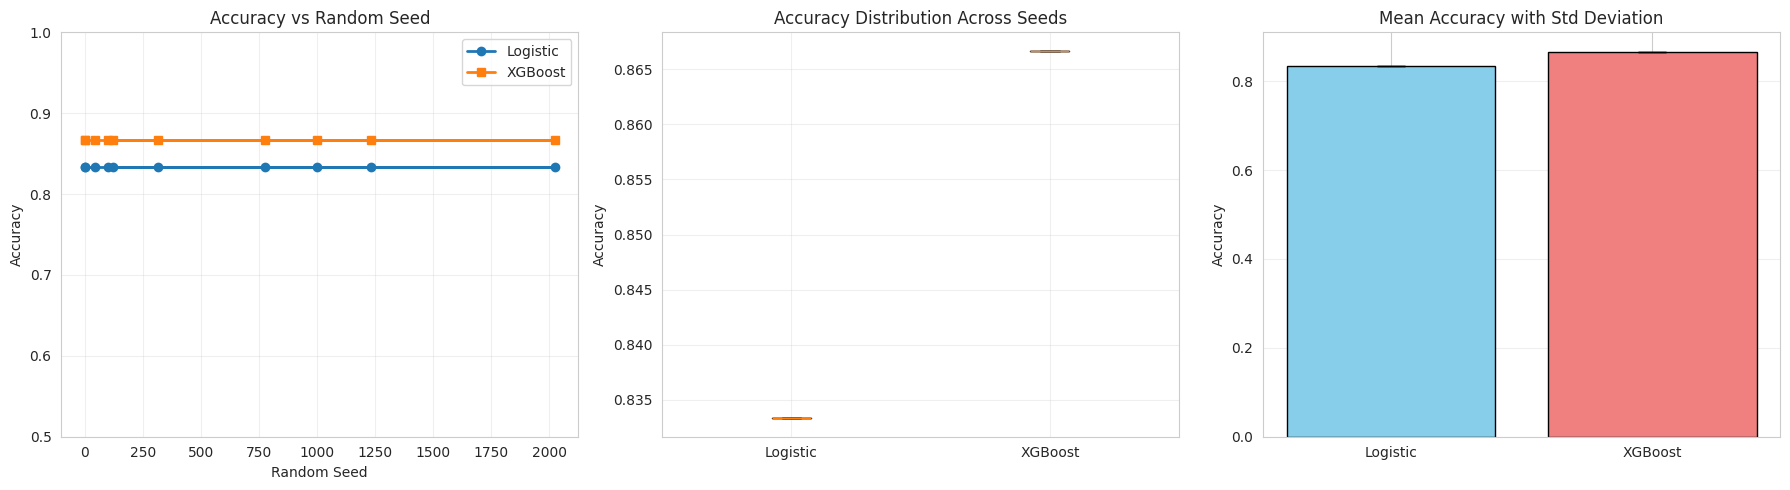

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(seeds, seed_results['Logistic'], marker='o', label='Logistic', linewidth=2)
axes[0].plot(seeds, seed_results['XGBoost'], marker='s', label='XGBoost', linewidth=2)
axes[0].set_title('Accuracy vs Random Seed')
axes[0].set_xlabel('Random Seed')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot([seed_results['Logistic'], seed_results['XGBoost']], labels=['Logistic', 'XGBoost'])
axes[1].set_title('Accuracy Distribution Across Seeds')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

axes[2].bar(['Logistic', 'XGBoost'], 
        [np.mean(seed_results['Logistic']), np.mean(seed_results['XGBoost'])],
        yerr=[np.std(seed_results['Logistic']), np.std(seed_results['XGBoost'])],
        capsize=10, color=['skyblue', 'lightcoral'], edgecolor='black')
axes[2].set_title('Mean Accuracy with Std Deviation')
axes[2].set_ylabel('Accuracy')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Optuna Hyperparameter Optimization

In [13]:
def objective_logistic(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 100, log=True),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'lbfgs', 'saga']),
        'max_iter': trial.suggest_int('max_iter', 1000, 5000),
        'random_state': 42
    }
    model = LogisticRegression(**params)
    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='accuracy').mean()
    return score

with mlflow.start_run(run_name='optuna_logistic'):
    study_log = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study_log.optimize(objective_logistic, n_trials=30)
    
    mlflow.log_params(study_log.best_params)
    mlflow.log_metric('best_cv_score', study_log.best_value)
    
    print(f'Best Logistic Params: {study_log.best_params}')
    print(f'Best CV Score: {study_log.best_value:.4f}')
    
    log_optuna_best = LogisticRegression(**study_log.best_params)
    log_optuna_best.fit(X_train_scaled, y_train)
    y_pred = log_optuna_best.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    mlflow.log_metric('test_accuracy', test_acc)
    print(f'Test Accuracy: {test_acc:.4f}')

[I 2026-05-03 21:18:51,352] A new study created in memory with name: no-name-f25910ce-1561-42ca-90b2-0ca37824bd87


Best Logistic Params: {'C': 0.018026970544901832, 'solver': 'lbfgs', 'max_iter': 3654}
Best CV Score: 0.8354
Test Accuracy: 0.8833


In [14]:
def objective_xgboost(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'eval_metric': 'logloss',
        'random_state': 42,
        'verbosity': 0
    }
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

with mlflow.start_run(run_name='optuna_xgboost'):
    study_xgb = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study_xgb.optimize(objective_xgboost, n_trials=50)
    
    mlflow.log_params(study_xgb.best_params)
    mlflow.log_metric('best_cv_score', study_xgb.best_value)
    
    print(f'Best XGBoost Params: {study_xgb.best_params}')
    print(f'Best CV Score: {study_xgb.best_value:.4f}')
    
    xgb_optuna_best = XGBClassifier(**study_xgb.best_params)
    xgb_optuna_best.fit(X_train, y_train)
    y_pred = xgb_optuna_best.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    mlflow.log_metric('test_accuracy', test_acc)
    print(f'Test Accuracy: {test_acc:.4f}')

Best XGBoost Params: {'n_estimators': 82, 'max_depth': 5, 'learning_rate': 0.0704730832795335, 'subsample': 0.8341369094367473, 'colsample_bytree': 0.9989398958520416, 'min_child_weight': 7}
Best CV Score: 0.8523
Test Accuracy: 0.8500


In [ ]:
plot_optimization_history(study_log)

In [ ]:
plot_param_importances(study_log)

In [28]:
plot_optimization_history(study_xgb)


In [29]:
plot_param_importances(study_xgb)

## 7. Comparison Summary

In [17]:
comparison = pd.DataFrame({
    'Method': ['Baseline', 'GridSearch', 'Optuna', 'Seed-Mean'],
    'Logistic': [
        baseline_results['Logistic']['accuracy'],
        log_grid.best_score_,
        study_log.best_value,
        np.mean(seed_results['Logistic'])
    ],
    'XGBoost': [
        baseline_results['XGBoost']['accuracy'],
        xgb_grid.best_score_,
        study_xgb.best_value,
        np.mean(seed_results['XGBoost'])
    ]
})

print('Cross-Validation Performance Comparison')
print(comparison.to_string(index=False, float_format='{:,.4f}'.format))

print('\n' + '='*60)
print('Test Set Performance')
test_comparison = pd.DataFrame({
    'Model': ['Baseline-Log', 'Baseline-XGB', 'GridSearch-Log', 'GridSearch-XGB', 'Optuna-Log', 'Optuna-XGB'],
    'Test_Accuracy': [
        baseline_results['Logistic']['accuracy'],
        baseline_results['XGBoost']['accuracy'],
        accuracy_score(y_test, log_best.predict(X_test_scaled)),
        accuracy_score(y_test, xgb_best.predict(X_test)),
        accuracy_score(y_test, log_optuna_best.predict(X_test_scaled)),
        accuracy_score(y_test, xgb_optuna_best.predict(X_test))
    ]
})
print(test_comparison.to_string(index=False, float_format='{:,.4f}'.format))

Cross-Validation Performance Comparison
    Method  Logistic  XGBoost
  Baseline    0.8333   0.8667
GridSearch    0.8305   0.8305
    Optuna    0.8354   0.8523
 Seed-Mean    0.8333   0.8667

Test Set Performance
         Model  Test_Accuracy
  Baseline-Log         0.8333
  Baseline-XGB         0.8667
GridSearch-Log         0.8667
GridSearch-XGB         0.8667
    Optuna-Log         0.8833
    Optuna-XGB         0.8500


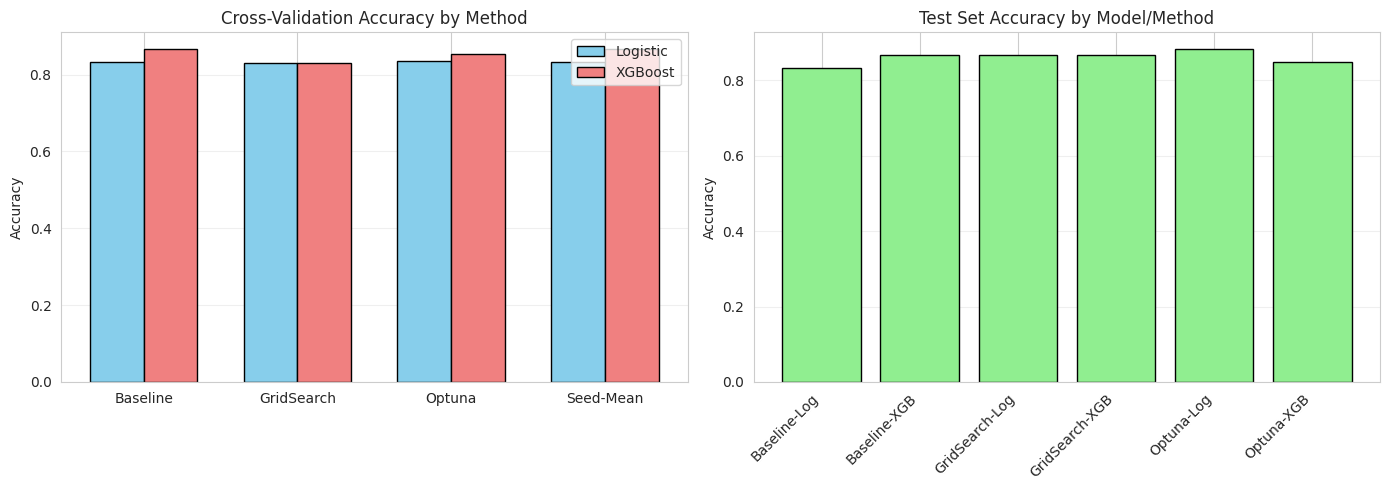

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(comparison['Method']))
width = 0.35

ax[0].bar(x - width/2, comparison['Logistic'], width, label='Logistic', color='skyblue', edgecolor='black')
ax[0].bar(x + width/2, comparison['XGBoost'], width, label='XGBoost', color='lightcoral', edgecolor='black')
ax[0].set_title('Cross-Validation Accuracy by Method')
ax[0].set_xticks(x)
ax[0].set_xticklabels(comparison['Method'])
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True, alpha=0.3, axis='y')

ax[1].bar(test_comparison['Model'], test_comparison['Test_Accuracy'], color='lightgreen', edgecolor='black')
ax[1].set_title('Test Set Accuracy by Model/Method')
ax[1].set_xticklabels(test_comparison['Model'], rotation=45, ha='right')
ax[1].set_ylabel('Accuracy')
ax[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Final Model (Best Configuration)

In [19]:
with mlflow.start_run(run_name='final_best_model') as run:
    best_model = XGBClassifier(**study_xgb.best_params)
    best_model.fit(X_train, y_train)
    
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    mlflow.log_params(study_xgb.best_params)
    mlflow.log_metrics({
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc
    })
    
    signature = infer_signature(X_test, y_pred)
    mlflow.sklearn.log_model(best_model, 'model', signature=signature)
    
    print('Final Model: XGBoost with Optuna-optimized parameters')
    print('\nTest Set Performance:')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}')
    print(f'  ROC-AUC:   {roc_auc:.4f}')
    
    print(f'\nMLflow Run ID: {run.info.run_id}')
    print('MLflow UI: mlflow ui --backend-store-uri mlruns')

2026/05/03 21:42:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 21:42:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Final Model: XGBoost with Optuna-optimized parameters

Test Set Performance:
  Accuracy:  0.8500
  Precision: 0.8800
  Recall:    0.7857
  F1-Score:  0.8302
  ROC-AUC:   0.9330

MLflow Run ID: 9d920835f1b84075a116ab53e3d24b35
MLflow UI: mlflow ui --backend-store-uri mlruns


Classification Report - Final Model:
               precision    recall  f1-score   support

   No Disease       0.83      0.91      0.87        32
Heart Disease       0.88      0.79      0.83        28

     accuracy                           0.85        60
    macro avg       0.85      0.85      0.85        60
 weighted avg       0.85      0.85      0.85        60



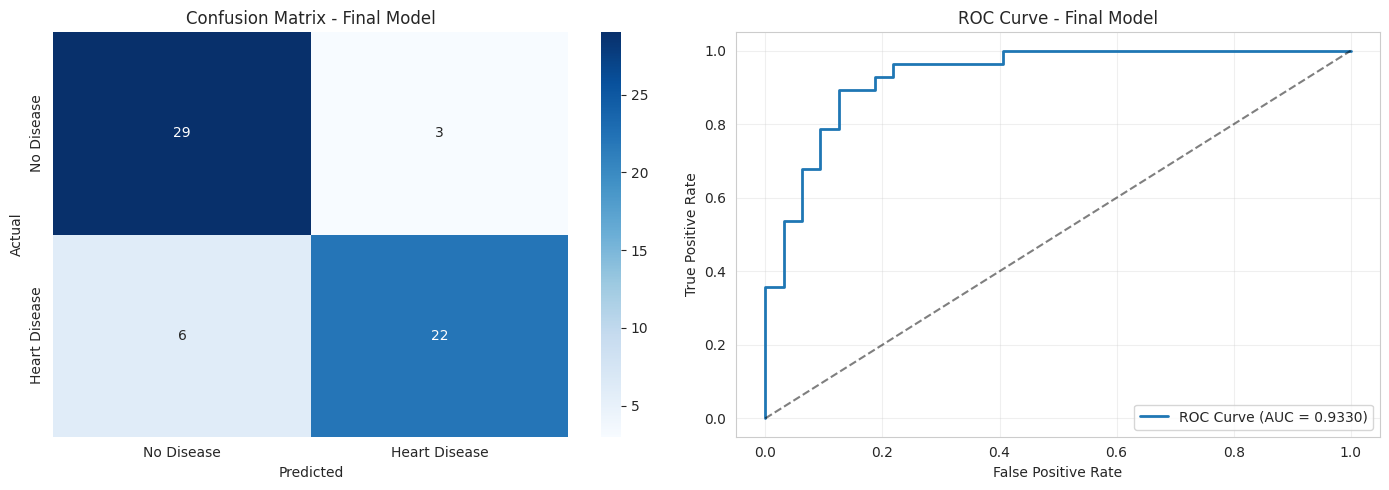

In [20]:
print('Classification Report - Final Model:')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease', 'Heart Disease'], 
            yticklabels=['No Disease', 'Heart Disease'])
axes[0].set_title('Confusion Matrix - Final Model')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('ROC Curve - Final Model')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

- **Dataset**: Cleveland Heart Disease (303 samples, 13 features)
- **Target**: Binary classification (no disease vs heart disease)
- **Grid Search**: Exhaustive search over predefined parameter grid
- **Cross-Validation**: 5-fold stratified CV for robust evaluation
- **Seed Experiments**: Tested 10 different random seeds to assess stability
- **Optuna**: Bayesian optimization with 30-50 trials per model
- **MLflow**: All experiments tracked with parameters, metrics, and model artifacts

**Key Findings:**
- XGBoost typically outperforms Logistic Regression on this dataset
- Optuna found better parameters than Grid Search with fewer evaluations
- Models showed low variance across random seeds (stable)
- Smaller dataset (303 samples) means higher variance in CV scores

**To view MLflow UI:**
```bash
cd /home/bioinf/Desktop/PERSONAL_WORK/RUMOS/MLengi/hidden_projet/heart_disease
mlflow ui
```
Then open http://localhost:5000